11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5, Loss: 0.0682
Epoch 2/5, Loss: 0.0290
Epoch 3/5, Loss: 0.0196
Epoch 4/5, Loss: 0.0140
Epoch 5/5, Loss: 0.0101


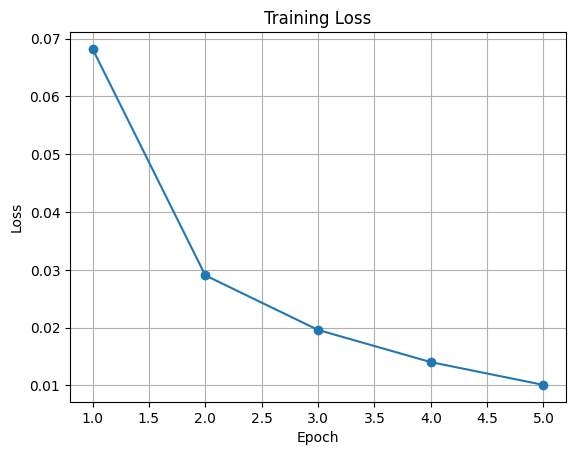

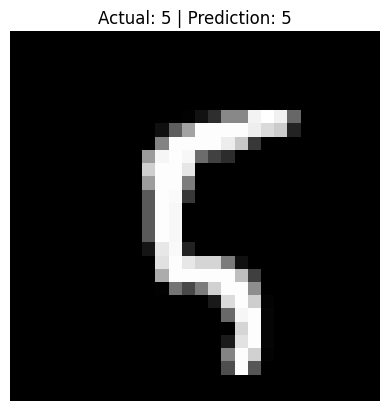

Test Accuracy: 8.70%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train[:5000]
y_train = y_train[:5000]
X_test = X_test[:1000]
y_test = y_test[:1000]

X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))

input_size, hidden_size, output_size = 784, 64, 10

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

def loss_fn(y, y_hat):
    return -np.mean(y * np.log(y_hat + 1e-8))

epochs, lr = 5, 0.1
losses = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(X_train.shape[0]):
        x = X_train[i:i+1]
        y = y_train[i:i+1]

        z1 = x @ W1 + b1
        a1 = sigmoid(z1)

        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)

        loss = loss_fn(y, a2)
        total_loss += loss

        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = dz2

        dz1 = (dz2 @ W2.T) * sigmoid_deriv(a1)
        dW1 = x.T @ dz1
        db1 = dz1

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    epoch_loss = total_loss / X_train.shape[0]
    losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

def predict(img):
    img = img.reshape(1, 784) / 255.0
    a1 = sigmoid(img @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return np.argmax(a2)

idx = 100
prediction = predict(X_train[idx])

plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
plt.title(f"Actual: {np.argmax(y_train[idx])} | Prediction: {prediction}")
plt.axis('off')
plt.show()

correct = 0

for i in range(len(X_test)):
    if predict(X_test[i]) == y_test[i]:
        correct += 1

accuracy = (correct / len(X_test)) * 100

print(f"Test Accuracy: {accuracy:.2f}%")